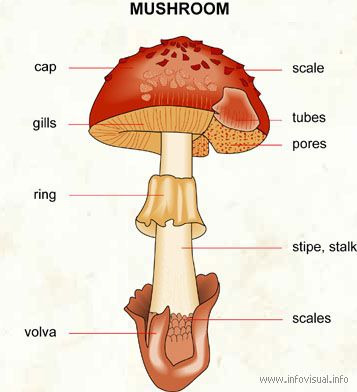

In [3]:
from IPython.display import Image
Image("0ac64fb5a9c29823572de772f4ba1ff1.jpg") #导入图片

classes: edible=e, poisonous=p

cap-shape: bell=b,conical=c,convex=x,flat=f, knobbed=k,sunken=s

cap-surface: fibrous=f,grooves=g,scaly=y,smooth=s

cap-color: brown=n,buff=b,cinnamon=c,gray=g,green=r,pink=p,purple=u,red=e,white=w,yellow=y

bruises: bruises=t,no=f

odor: almond=a,anise=l,creosote=c,fishy=y,foul=f,musty=m,none=n,pungent=p,spicy=s

gill-attachment: attached=a,descending=d,free=f,notched=n

gill-spacing: close=c,crowded=w,distant=d

gill-size: broad=b,narrow=n

gill-color: black=k,brown=n,buff=b,chocolate=h,gray=g, green=r,orange=o,pink=p,purple=u,red=e,white=w,yellow=y

stalk-shape: enlarging=e,tapering=t

stalk-root: bulbous=b,club=c,cup=u,equal=e,rhizomorphs=z,rooted=r,missing=?

stalk-surface-above-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-surface-below-ring: fibrous=f,scaly=y,silky=k,smooth=s

stalk-color-above-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

stalk-color-below-ring: brown=n,buff=b,cinnamon=c,gray=g,orange=o,pink=p,red=e,white=w,yellow=y

veil-type: partial=p,universal=u

veil-color: brown=n,orange=o,white=w,yellow=y

ring-number: none=n,one=o,two=t

ring-type: cobwebby=c,evanescent=e,flaring=f,large=l,none=n,pendant=p,sheathing=s,zone=z

spore-print-color: black=k,brown=n,buff=b,chocolate=h,green=r,orange=o,purple=u,white=w,yellow=y

population: abundant=a,clustered=c,numerous=n,scattered=s,several=v,solitary=y

habitat: grasses=g,leaves=l,meadows=m,paths=p,urban=u,waste=w,woods=d

In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt

In [5]:
mushrooms = pd.read_csv('mushrooms.csv') #导入文件

In [6]:
mushrooms.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [7]:
mushrooms.shape #查看数组形状

(8124, 23)

In [8]:
mushrooms.describe() #对数值特征进行统计

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


<Axes: xlabel='class,cap-color'>

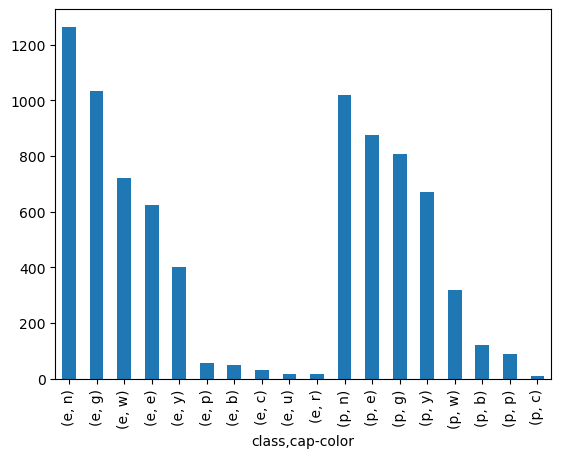

In [9]:
mushrooms.groupby('class')['cap-color'].value_counts().plot(kind='bar') #按照class分组，再计算组内每一种cap-color的数量 画柱状图

按照cap-color进行统计

In [10]:
#Obtain total number of mushrooms for each 'cap-color' (Entire DataFrame)
cap_colors = mushrooms['cap-color'].value_counts() #按照cap-color对数据进行计数统计，得到的是索引和数量
cap_colors

cap-color
n    2284
g    1840
e    1500
y    1072
w    1040
b     168
p     144
c      44
u      16
r      16
Name: count, dtype: int64

In [13]:
m_height = cap_colors.values.tolist() #Provides numerical values 取数量变成列表
m_height

[2284, 1840, 1500, 1072, 1040, 168, 144, 44, 16, 16]

In [14]:
cap_colors.axes #Provides row labels 取轴

[Index(['n', 'g', 'e', 'y', 'w', 'b', 'p', 'c', 'u', 'r'], dtype='object', name='cap-color')]

In [15]:
cap_color_labels = cap_colors.axes[0].tolist() #Converts index object to list 取索引列变成列表
cap_color_labels

['n', 'g', 'e', 'y', 'w', 'b', 'p', 'c', 'u', 'r']

[Text(0, 0, 'brown'),
 Text(1, 0, 'gray'),
 Text(2, 0, 'red'),
 Text(3, 0, 'yellow'),
 Text(4, 0, 'white'),
 Text(5, 0, 'buff'),
 Text(6, 0, 'pink'),
 Text(7, 0, 'cinnamon'),
 Text(8, 0, 'purple'),
 Text(9, 0, 'green')]

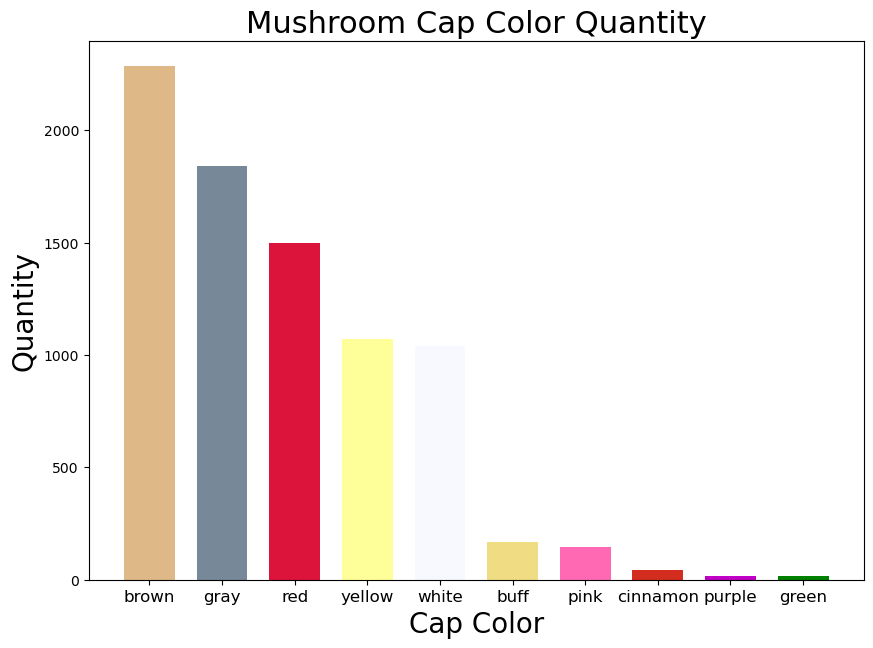

In [16]:
#=====PLOT Preparations and Plotting====#
ind = np.arange(10)  # the x locations for the groups 生成数组
width = 0.7        # the width of the bars
colors = ['#DEB887','#778899','#DC143C','#FFFF99','#f8f8ff','#F0DC82','#FF69B4','#D22D1E','#C000C5','g']
#FFFFF0
fig, ax = plt.subplots(figsize=(10,7)) #ax是轴 创建画布
mushroom_bars = ax.bar(ind, m_height , width, color=colors) #绘制柱形图

#Add some text for labels, title and axes ticks
ax.set_xlabel("Cap Color",fontsize=20) #x轴标签
ax.set_ylabel('Quantity',fontsize=20) #y轴标签
ax.set_title('Mushroom Cap Color Quantity',fontsize=22) #图名
ax.set_xticks(ind) #Positioning on the x axis
ax.set_xticklabels(('brown', 'gray','red','yellow','white','buff','pink','cinnamon','purple','green'),
                  fontsize = 12)
    
#plt.show() #Display bars. 

在每种颜色内，再统计出有毒和可食用蘑菇的数量

In [22]:
poisonous_cc = [] #Poisonous color cap list 有毒的蘑菇
edible_cc = []    #Edible color cap list 可食用的蘑菇
for capColor in cap_color_labels:
    size = len(mushrooms[mushrooms['cap-color'] == capColor].index) #计算不同cap-color的蘑菇数量 
    edibles = len(mushrooms[(mushrooms['cap-color'] == capColor) & (mushrooms['class'] == 'e')].index) #计算是可食用蘑菇的不同cap-cplor的数量 判断蘑菇的cap-color和是否可食用，再对行数进行统计
    edible_cc.append(edibles) #把得到的结果放进列表-可食用 
    poisonous_cc.append(size-edibles)  #把得到的结果放进列表-有毒 总数-可食用

16


In [19]:
print(edible_cc)
print(poisonous_cc)

[1264, 1032, 624, 400, 720, 48, 56, 32, 16, 16]
[1020, 808, 876, 672, 320, 120, 88, 12, 0, 0]


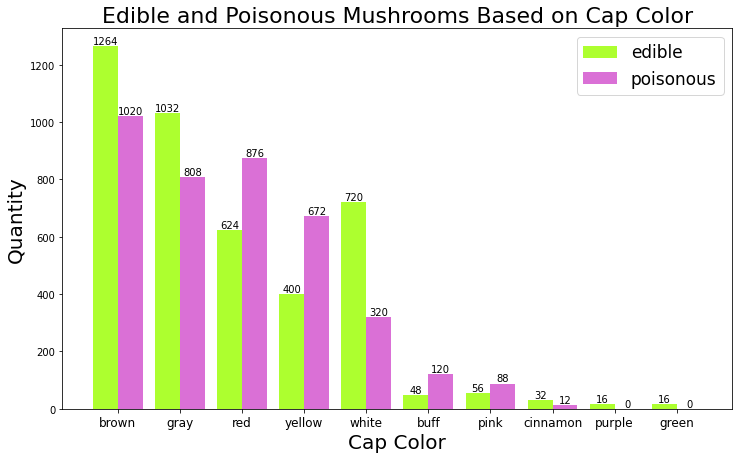

In [27]:
#=====PLOT Preparations and Plotting====#
width = 0.40
fig, ax = plt.subplots(figsize=(12,7)) #绘制画布
edible_bars = ax.bar(ind, edible_cc , width, color='#ADFF2F') #柱状图 横坐标是ind
poison_bars = ax.bar(ind+width, poisonous_cc , width, color='#DA70D6') #柱状图 横坐标是ind+一个宽度，为了错位

#Add some text for labels, title and axes ticks
ax.set_xlabel("Cap Color",fontsize=20)
ax.set_ylabel('Quantity',fontsize=20)
ax.set_title('Edible and Poisonous Mushrooms Based on Cap Color',fontsize=22)
ax.set_xticks(ind + width / 2) #Positioning on the x axis 设置x轴的刻度
ax.set_xticklabels(('brown', 'gray','red','yellow','white','buff','pink','cinnamon','purple','green'),
                  fontsize = 12) #设置x轴刻度标签
ax.legend((edible_bars,poison_bars),('edible','poisonous'),fontsize=17) #图例


In [ ]:
按照odor进行统计

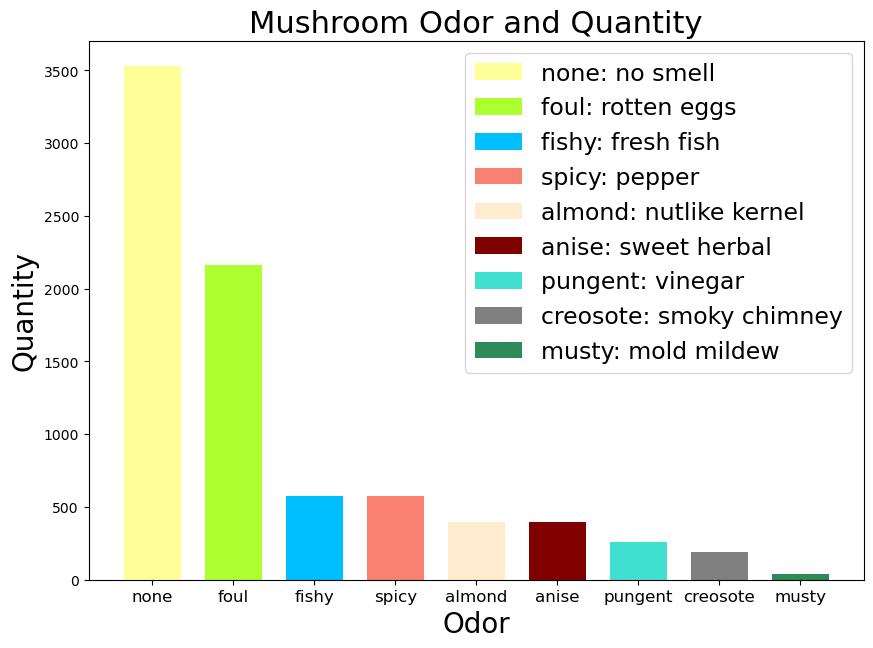

In [24]:
#Obtain total number of mushrooms for each 'odor' (Entire DataFrame)
odors = mushrooms['odor'].value_counts() #按照odor对数据进行计数统计
odor_height = odors.values.tolist() #Provides numerical values 
odor_labels = odors.axes[0].tolist() #Converts index labels object to list

#=====PLOT Preparations and Plotting====#
width = 0.7 
ind = np.arange(9)  # the x locations for the groups
colors = ['#FFFF99','#ADFF2F','#00BFFF','#FA8072','#FFEBCD','#800000','#40E0D0','#808080','#2E8B57']

fig, ax = plt.subplots(figsize=(10,7)) #绘制画布
odor_bars = ax.bar(ind, odor_height , width, color=colors) #柱状图，x轴是9个刻度，y轴按odor计数

#Add some text for labels, title and axes ticks
ax.set_xlabel("Odor",fontsize=20) #x轴标签，字体大小20
ax.set_ylabel('Quantity',fontsize=20) #y轴标签，字体大小20
ax.set_title('Mushroom Odor and Quantity',fontsize=22) #图名，字体大小22
ax.set_xticks(ind) #Positioning on the x axis x轴刻度
ax.set_xticklabels(('none', 'foul','fishy','spicy','almond','anise','pungent','creosote','musty'),
                  fontsize = 12) #x轴刻度标签
ax.legend(odor_bars, ['none: no smell','foul: rotten eggs', 'fishy: fresh fish','spicy: pepper',
                      'almond: nutlike kernel', 'anise: sweet herbal', 'pungent: vinegar',
                     'creosote: smoky chimney', 'musty: mold mildew'],fontsize=17) #图例

[3408, 0, 0, 0, 400, 400, 0, 0, 0]
[120, 2160, 576, 576, 0, 0, 256, 192, 36]


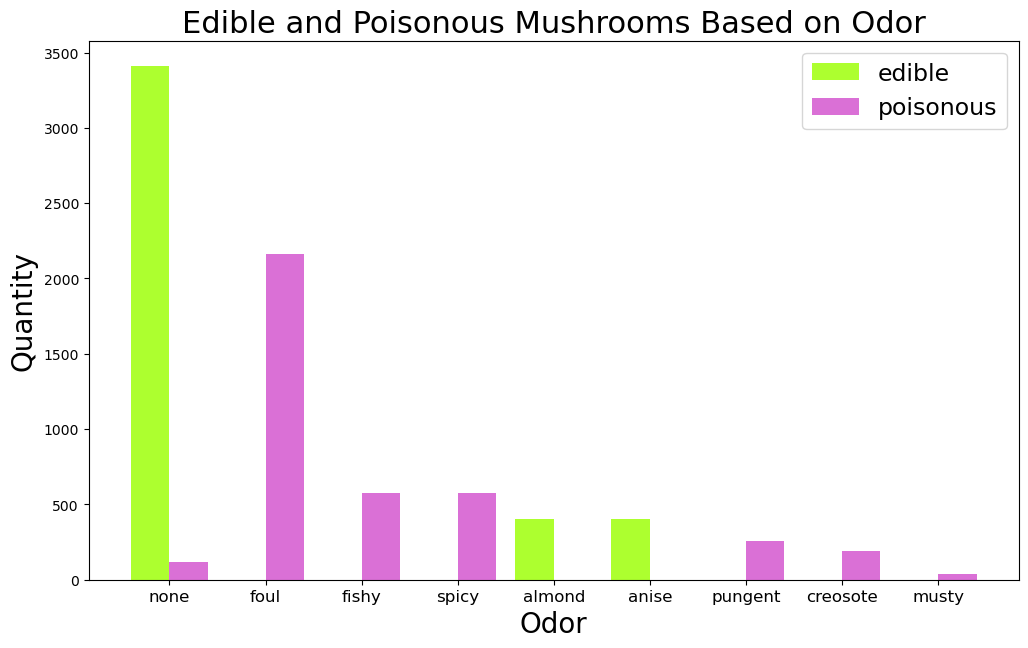

In [25]:
poisonous_od = [] #Poisonous odor list
edible_od = []    #Edible odor list
for odor in odor_labels:
    size = len(mushrooms[mushrooms['odor'] == odor].index) #计算不同odor的蘑菇数量 
    edibles = len(mushrooms[(mushrooms['odor'] == odor) & (mushrooms['class'] == 'e')].index) #计算是可食用蘑菇的不同odor的数量 判断蘑菇的odor和是否可食用，再对行数进行统计
    edible_od.append(edibles) #把得到的结果放进列表-可食用
    poisonous_od.append(size-edibles) #把得到的结果放进列表-有毒
                        
#=====PLOT Preparations and Plotting====#
width = 0.40
fig, ax = plt.subplots(figsize=(12,7))
edible_bars = ax.bar(ind, edible_od , width, color='#ADFF2F')
poison_bars = ax.bar(ind+width, poisonous_od , width, color='#DA70D6')

#Add some text for labels, title and axes ticks
ax.set_xlabel("Odor",fontsize=20)
ax.set_ylabel('Quantity',fontsize=20)
ax.set_title('Edible and Poisonous Mushrooms Based on Odor',fontsize=22)
ax.set_xticks(ind + width / 2) #Positioning on the x axis
ax.set_xticklabels(('none', 'foul','fishy','spicy','almond','anise','pungent','creosote','musty'),
                  fontsize = 12)
ax.legend((edible_bars,poison_bars),('edible','poisonous'),fontsize=17)

print(edible_od)
print(poisonous_od)

In [ ]:
按照population进行统计

[4040, 1712, 1248, 400, 384, 340]


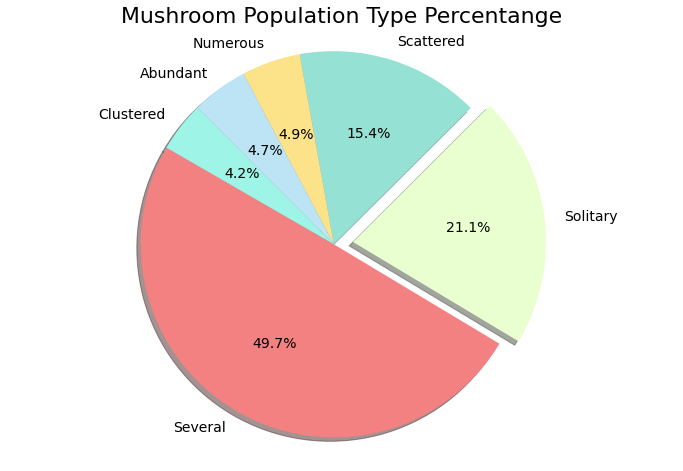

In [14]:
#Get the population types and its values for Single Pie chart
populations = mushrooms['population'].value_counts() #按照population对数据进行计数统计
pop_size = populations.values.tolist() #Provides numerical values
pop_types = populations.axes[0].tolist() #Converts index labels object to list
print(pop_size)
# Data to plot
pop_labels = 'Several', 'Solitary', 'Scattered', 'Numerous', 'Abundant', 'Clustered' #准备标签名
colors = ['#F38181','#EAFFD0','#95E1D3','#FCE38A','#BDE4F4','#9EF4E6'] #准备颜色
explode = (0, 0.1, 0, 0, 0, 0)  # explode 1st slice explode设置饼图内部分距离中心的偏移量
fig = plt.figure(figsize=(12,8)) 
# Plot
plt.title('Mushroom Population Type Percentange', fontsize=22) 
patches, texts, autotexts = plt.pie(pop_size, explode=explode, labels=pop_labels, colors=colors,
        autopct='%1.1f%%', shadow=True, startangle=150) #绘制饼图，并返回三个变量 autopct：显示每个部分所占的百分比 startangle：起始角度为150度
for text,autotext in zip(texts,autotexts): #设置每部分的标签及字体，也可在上一步使用textprops
    text.set_fontsize(14)
    autotext.set_fontsize(14)

plt.axis('equal')
plt.show()

In [17]:
#DOUBLE PIE CHART 
poisonous_pop = [] #Poisonous population type list
edible_pop = []    #Edible population type list
for pop in pop_types: 
    size = len(mushrooms[mushrooms['population'] == pop].index)
    edibles = len(mushrooms[(mushrooms['population'] == pop) & (mushrooms['class'] == 'e')].index)
    edible_pop.append(edibles) #Gets edibles
    poisonous_pop.append(size-edibles) #Gets poisonous
print(edible_pop) #可食用
print(poisonous_pop) #有毒的

[1192, 1064, 880, 400, 384, 288]
[2848, 648, 368, 0, 0, 52]


In [19]:
combine_ed_poi = [] #为合并一起创建空列表
for i in range(0,len(edible_pop)): #Combines both edible and poisonous in a single list. 将可食用蘑菇和有毒蘑菇的数量列表合并成一个列表
    combine_ed_poi.append(edible_pop[i])
    combine_ed_poi.append(poisonous_pop[i]) 
print(combine_ed_poi) #把每个population的分为无毒和有毒

[1192, 2848, 1064, 648, 880, 368, 400, 0, 384, 0, 288, 52]


In [50]:
#Percetanges for edible and poisonous
percentages_e_p=combine_ed_poi/np.cumsum(combine_ed_poi)[len(combine_ed_poi)-1] #np.cumsum(combine_ed_poi)累加，len(combine_ed_poi)-1输出最后一个值，求比例
percentages_e_p=percentages_e_p*100
percentages_e_p=np.round(percentages_e_p,2) #只保留小数点后两位
percentages_e_p = [str(x) for x in percentages_e_p] #转化成字符串
percentages_e_p = [x+'%' for x in percentages_e_p] #拼接百分号

In [ ]:
#!!!!演示内标签相关属性，起始角度设置为30
#plt.subplot(243)
#plt.pie(x, autopct='%1.1f%%',pctdistance=0.4,startangle=30)

In [51]:
print(percentages_e_p)

['14.67%', '35.06%', '13.1%', '7.98%', '10.83%', '4.53%', '4.92%', '0.0%', '4.73%', '0.0%', '3.55%', '0.64%']


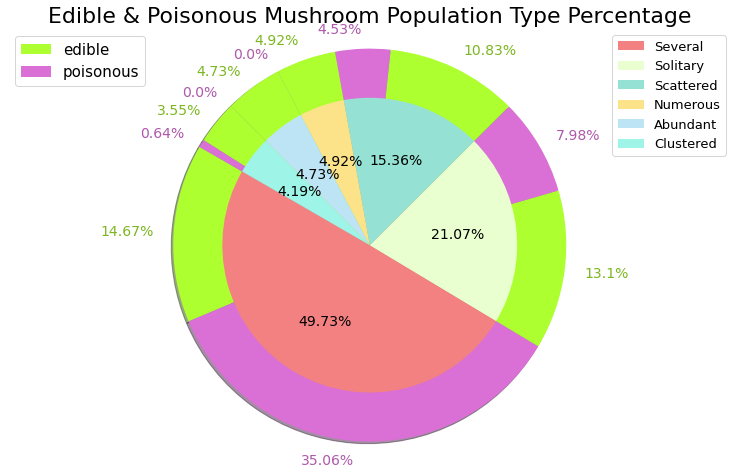

In [54]:
#Preparations for DOUBLE pie chart.
fig = plt.subplots(figsize=(13,8))
plt.title('Edible & Poisonous Mushroom Population Type Percentage', fontsize=22)
#===First pie===
patches1, texts1 = plt.pie(combine_ed_poi,radius = 2, labels= percentages_e_p,
                                colors=['#ADFF2F','#DA70D6'], shadow=True, startangle=150)
for i in range(0,len(texts1)): #对每个扇形块的标签进行颜色和字体大小的设置
    if(i%2==0): #i是否为偶数
        texts1[i].set_color('#7CB721') #Color % labels with dark green
    else:
        texts1[i].set_color('#AE59AB') # " " dark purple
    texts1[i].set_fontsize(14)         #make labels bigger

#===Second pie===
patches2, texts2, autotexts2 = plt.pie(pop_size, colors=colors, radius = 1.5,
        autopct='%1.2f%%', shadow=True, startangle=150,labeldistance= 2.2)
for aut in autotexts2:
    aut.set_fontsize(14)  #Inner autotext fontsize
    aut.set_horizontalalignment('center') #Center
#==Set 2 Legends to the plot.
first_legend   = plt.legend(patches1, ['edible','poisonous'], loc="upper left", fontsize=15)
second_ledgend = plt.legend(patches2, pop_labels, loc="best",fontsize=13)
plt.gca().add_artist(first_legend) #To display two legends 展示两个图例
#Align both pie charts in the same position
plt.axis('equal')
plt.show()

In [62]:
# one-hot encode 
from sklearn.preprocessing import OneHotEncoder
#categorical data
df = mushrooms.drop('class',axis=1) #按着列
y = mushrooms['class']
print(df.shape) #22个特征
print(y.shape)


(8124, 22)
(8124,)


In [64]:
#import pandas as pd
X = pd.get_dummies(df, columns = df.columns) #对每个特征进行独热编码
X.head()

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0,0,0,0,0,1,0,0,1,0,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,1,0,0,0,0,0,0,0,1,0,...,0,0,0,0,0,0,1,0,0,0
3,0,0,0,0,0,1,0,0,0,1,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0


In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1) #将数据分割为训练集和测试集
print(len(X_train))
print(len(y_train))
print(len(X_test))
print(len(y_test))

6499
6499
1625
1625


In [67]:
from sklearn.neural_network import MLPClassifier 
mlp = MLPClassifier(solver='adam',alpha=1e-5,hidden_layer_sizes=(3,3),random_state=1,max_iter=10000) #神经网络 3个隐藏层 每层有有3个神经元
mlp.fit(X_train,y_train)

MLPClassifier(activation='relu', alpha=1e-05, batch_size='auto', beta_1=0.9,
              beta_2=0.999, early_stopping=False, epsilon=1e-08,
              hidden_layer_sizes=(3, 3), learning_rate='constant',
              learning_rate_init=0.001, max_iter=10000, momentum=0.9,
              n_iter_no_change=10, nesterovs_momentum=True, power_t=0.5,
              random_state=1, shuffle=True, solver='adam', tol=0.0001,
              validation_fraction=0.1, verbose=False, warm_start=False)

In [69]:
mlp.score(X_test,y_test) #得分

C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\preprocessing\label.py:749: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  y = np.array(y > threshold, dtype=np.int)


1.0

In [70]:
from sklearn import linear_model
logreg=linear_model.LogisticRegression(C=1e5) #创建模型对象
logreg.fit(X_train,y_train) #训练
acc = logreg.score(X_test,y_test)
print(acc) #准确率

1.0


C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\least_angle.py:30: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  method='lar', copy_X=True, eps=np.finfo(np.float).eps,
C:\Users\frees\AppData\Roaming\Python\Python37\site-packages\sklearn\linear_model\least_angle.py:167: DeprecationWarning: `np.float` is a deprecated alias for the builtin `float`. To silence this warning, use `float` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.float64` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#depre